In [2]:
import numpy as np
import os
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns

from eval_utils import compare_aligned_data

In [3]:
data_dir = 'data'
label_dir = os.path.join(data_dir, 'int/lidar/lidar_by_site_32736_10m')
site_names = os.listdir(label_dir)


In [4]:
label_dir
eval_dir = os.path.join(data_dir, 'existing_reference_data/eth_maps_per_site_10m')
fns_eval = os.listdir(eval_dir)

In [5]:
res_by_site_name = {}
for site_name in site_names:
    tif_fns = os.listdir(os.path.join(label_dir, site_name))
    assert len(tif_fns) == 1
    tif_fn = tif_fns[0]
    label_fp = os.path.join(label_dir, site_name, tif_fn)
    
    with rasterio.open(label_fp) as f:
        labels = f.read()
        
    
    this_pred_fns = [x for x in fns_eval if site_name in x]
    assert len(this_pred_fns) == 1
    this_pred_fn = this_pred_fns[0]
    with rasterio.open(os.path.join(eval_dir,this_pred_fn)) as f:
        preds = f.read()
        
    res_by_site_name[site_name] = compare_aligned_data(labels, preds, return_vals=True)

Text(0.5, 1.0, 'eth map evaluated as predictions per cite')

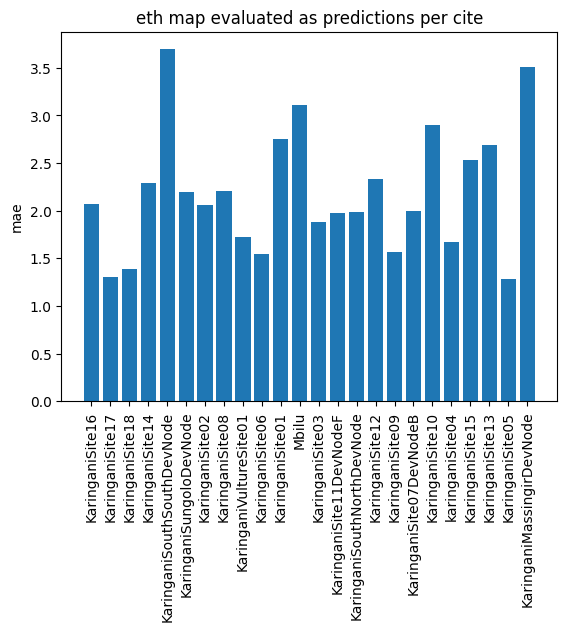

In [6]:
eval_metric = 'mae'
res_plot = np.array([res_by_site_name[x][eval_metric] for x in site_names])

fig, ax = plt.subplots()
ax.bar(np.arange(len(site_names)), res_plot)
ax.set_xticks(np.arange(len(site_names)));
ax.set_xticklabels(site_names, rotation=90);
ax.set_ylabel(eval_metric)
ax.set_title('eth map evaluated as predictions per cite')


# Visualize

In [7]:
vis_site_ids = ['KaringaniSite12', 'KaringaniSite16']

In [8]:
def plot_aligned_data(labels, preds, vis, title):
    fig, ax = plt.subplots(1,3, figsize=(24,8))
    ax[0].imshow(labels, vmin=0, vmax=15, interpolation=None, cmap='Greens')
    ax[1].imshow(preds, vmin=0, vmax=15, interpolation=None, cmap='Greens')
    ax[2].imshow(vis,  interpolation=None)
    
    ax[0].set_title('CHM labels (10m)')
    ax[1].set_title('reference/predicted values')
    ax[2].set_title('S2 image')
    for axis in ax:
        axis.axis('off')

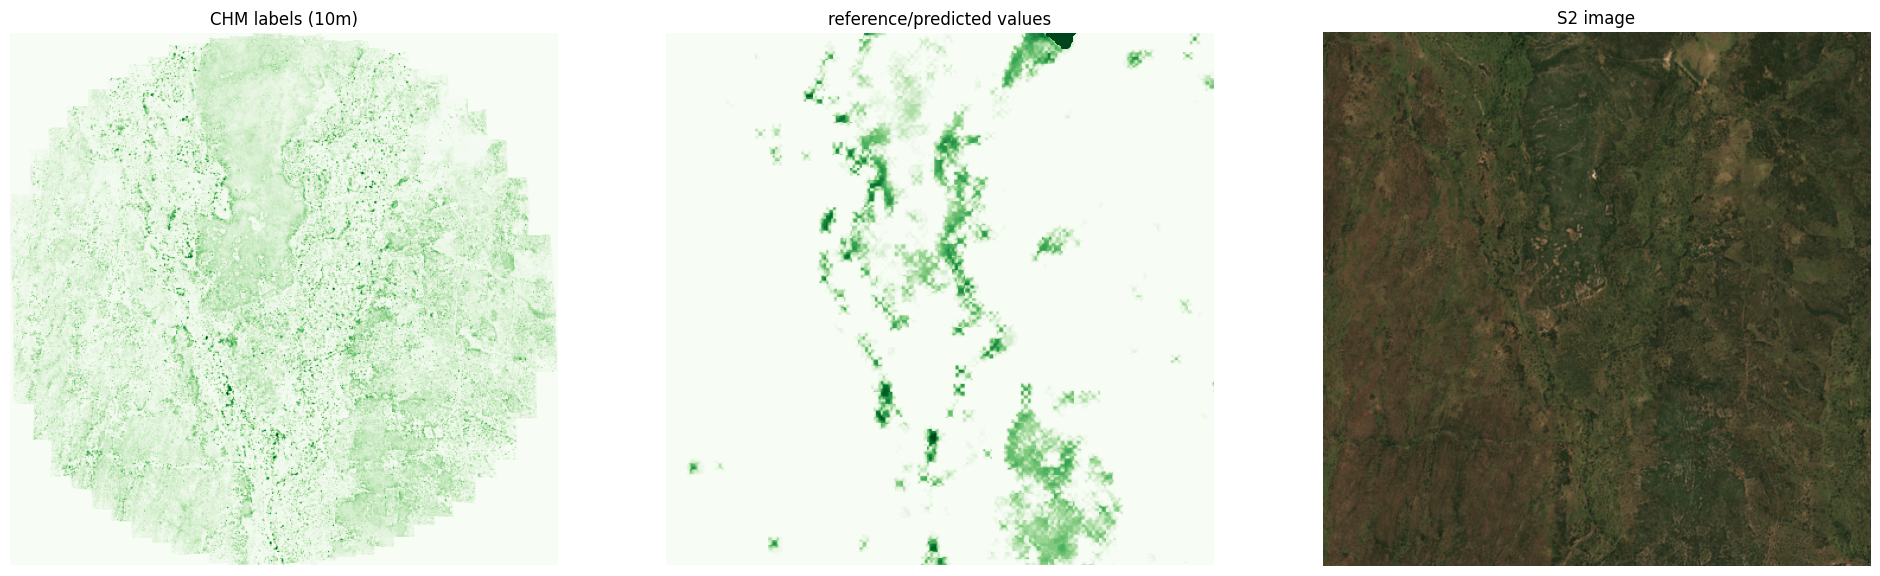

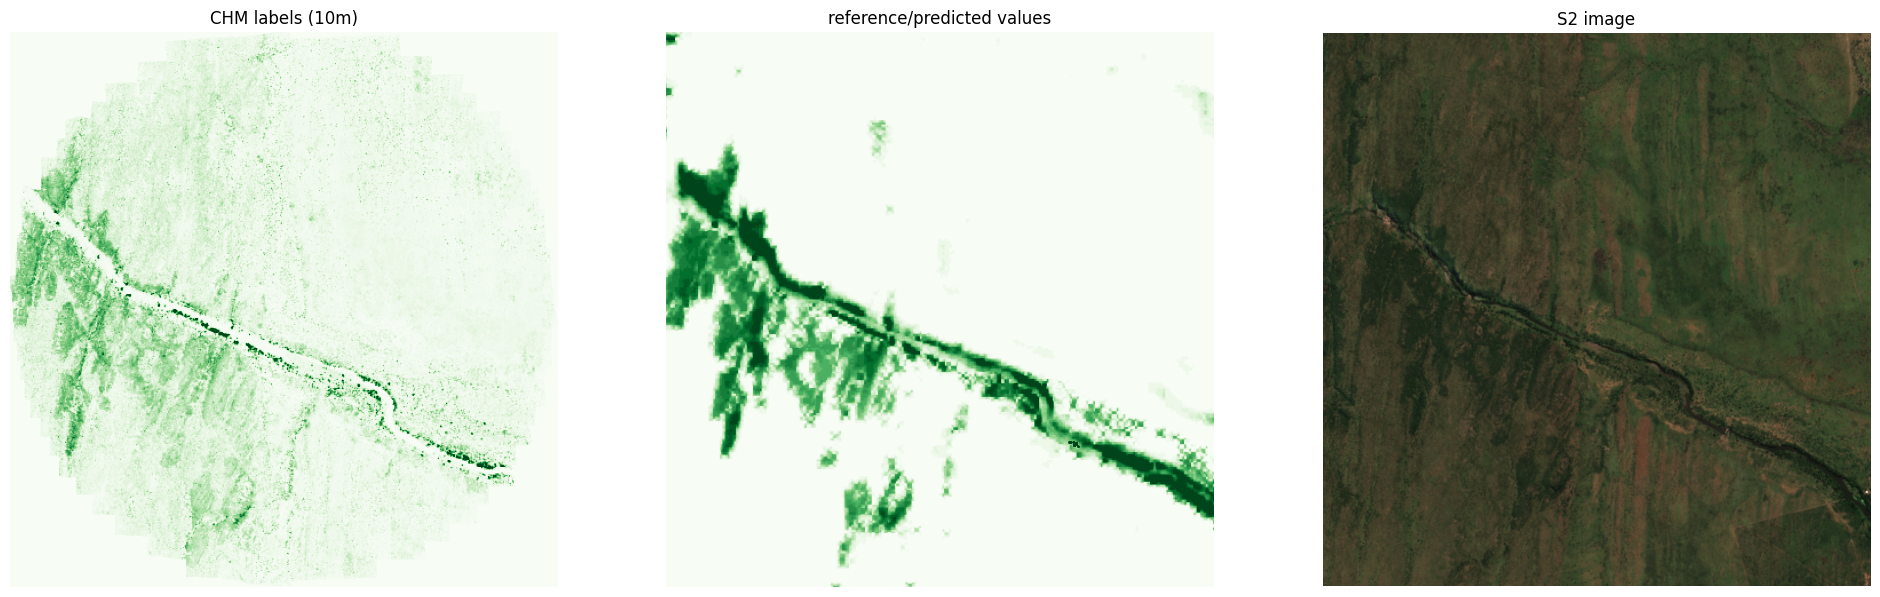

In [9]:
for eval_site_id in vis_site_ids:
    # load tif
    
    labels = res_by_site_name[eval_site_id]['labels'][0]
    preds = res_by_site_name[eval_site_id]['preds'][0]
    
    eval_input_dir = os.path.join(data_dir,f'int/sentinel/sentinel_by_site_32736_10m/{eval_site_id}')
    example_tif = [x for x in os.listdir(eval_input_dir) if x.endswith("TCI_10m.tif")][0]
    with rasterio.open(os.path.join(eval_input_dir, example_tif)) as f:
            vis = f.read().transpose(1,2,0)
    
    plot_aligned_data(labels, preds, vis = vis, title=f'ETH map {eval_site_id}')
    
    